---
title:  "SARIMA Model of Crime & Unemployment\\vspace{-2cm}"
format: html
number-sections: true
jupyter: python3
python: ~/venv/bin/python3
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings('ignore')

In [2]:
crime = pd.read_csv("rms_crime_incidents.csv")
unemployment = pd.read_csv('unemployment_wayne_county.csv')

# Crime Data

In [3]:
#| eval: false
crime.head()

,X,Y,incident_entry_id,nearest_intersection,offense_category,offense_description,state_offense_code,arrest_charge,charge_description,incident_occurred_at,...,report_number,scout_car_area,police_precinct,census_block_2020_geoid,neighborhood,council_district,zip_code,longitude,latitude,ESRI_OID
0,-83.241300,42.374040,1255424-2307,Wadsworth St & Fielding St,LARCENY,LARCENY - OTHER ...,2307,23007,LARCENY - OTHER ...,2025/03/11 04:00:00+00,...,2503170044,0603,06,2.616355e+14,Weatherby,7.0,48228.0,-83.241300,42.374040,1
1,-83.147703,42.340357,1380965-2601,McDonald St & Radcliffe St,FRAUD,FRAUD - FALSE PRETENSE / SWINDLE / CONFIDENCE ...,2601,26001,FRAUD - FALSE PRETENSE / SWINDLE / CONFIDENCE ...,2025/12/17 17:30:00+00,...,2601020174,0401,04,2.616353e+14,Claytown,6.0,48210.0,-83.147703,42.340357,2
2,-83.114223,42.357153,1389365-2900,Seebaldt St & Turner St,DAMAGE TO PROPERTY,DAMAGE TO PROPERTY ...,2900,29000,DAMAGE TO PROPERTY ...,2026/01/27 12:06:00+00,...,2601270059,1006,10,2.616353e+14,Midwest,6.0,48204.0,-83.114223,42.357153,3
3,-83.043401,42.424733,1363733-5701,Iowa St & Minnesota St,INVASION OF PRIVACY -OTHER,TRESPASS,5701,57001,TRESPASS,2025/11/17 01:24:00+00,...,2511160321,1108,11,2.616351e+14,Davison,3.0,48212.0,-83.043401,42.424733,4
4,-83.043401,42.424733,1363732-1301,Iowa St & Minnesota St,ASSAULT,ASSAULT AND BATTERY/SIMPLE ASSAULT,1301,13001,ASSAULT AND BATTERY/SIMPLE ASSAULT,2025/11/17 01:24:00+00,...,2511160321,1108,11,2.616351e+14,Davison,3.0,48212.0,-83.043401,42.424733,5


**Exploratory Data Analysis**

In [4]:
# Turn str into dates
crime['incident_occurred_at'] = pd.to_datetime(crime['incident_occurred_at'])

# monthly period
crime['Month'] = crime['incident_occurred_at'].dt.to_period('M')

# Aggregate counts over each month and year
# Starting from 2014
crime_monthly = crime.groupby('Month').size().reset_index(name='Incidents')
crime_monthly['Month'] = crime_monthly['Month'].dt.to_timestamp()
crime_monthly = crime_monthly[crime_monthly['Month'].dt.year >= 2017]

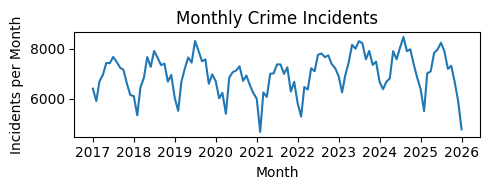

In [5]:
#| label: fig-time-plot-incidents
#| fig-cap: "Time plot of Incidents per Month"

plt.figure(figsize=(5, 2))
plt.title("Monthly Crime Incidents")
plt.plot(crime_monthly['Month'], crime_monthly['Incidents'], '-')
plt.xlabel('Month'); plt.ylabel('Incidents per Month')
plt.tight_layout(); plt.show()

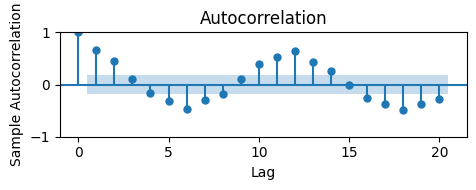

In [6]:
#| label: fig-acf-incidents
#| fig-cap: "Sample Autocorrelation function plot of Incidents per Month"

fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(crime_monthly['Incidents'], ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

**Model Fitting**

Models without splitting

In [7]:
monthly_incident_count = crime_monthly['Incidents']

crime_sarima1 = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(1, 1, 0, 12)).fit()

crime_sarima2 = SARIMAX(monthly_incident_count, order=(0,0,1), trend='c',seasonal_order=(0, 1, 1, 12)).fit()

crime_sarima3 = SARIMAX(monthly_incident_count, order=(1,0,1), trend='c',seasonal_order=(1, 1, 1, 12)).fit()

crime_sarima4 = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(2, 1, 0, 12)).fit()

crime_sarima5 = SARIMAX(monthly_incident_count, order=(0,0,1), trend='c',seasonal_order=(1, 1, 0, 12)).fit()

crime_sarima6 = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(1, 1, 1, 12)).fit()

crime_sarima7 = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(0, 1, 1, 12)).fit()

crime_sarima8 = SARIMAX(monthly_incident_count, order=(1,1,1), trend='c',seasonal_order=(1, 1, 1, 12)).fit()

crime_sarima9 = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(1, 0, 0,12)).fit()

crime_sarima10 = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(1, 1, 0, 12)).fit()

crime_sarima11 = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 1, 0,12)).fit()

crime_sarima12 = SARIMAX(monthly_incident_count, order=(0,1,1), trend='c', seasonal_order=(0, 1, 1,12)).fit()

AIC

In [8]:
crime_sarima1.aic.item()
crime_sarima2.aic.item()
crime_sarima3.aic.item()
crime_sarima4.aic.item()
crime_sarima5.aic.item()
crime_sarima6.aic.item()
crime_sarima7.aic.item()
crime_sarima8.aic.item()
crime_sarima9.aic.item()
crime_sarima10.aic.item()
crime_sarima11.aic.item()
crime_sarima12.aic.item()

1411.615496793355

In [9]:
# crime_sarima1.summary() # intercept not significant
# crime_sarima3.summary() # ma.L1 not significant
# crime_sarima4.summary() # intercept and ar.S.L24 not significant
crime_sarima6.summary() # all significant
# crime_sarima7.summary() # all significant besides intercept
# crime_sarima8.summary() # intercept, ar.L1, ar.S.L12 not significant
crime_sarima9.summary() # intercept not significant
#crime_sarima10.summary() # intercept is not significant
# crime_sarima12.summary() # intercept not significant, but this is a commonly used model

print(crime_sarima6.summary().tables[1])
print(crime_sarima9.summary().tables[1])
print(crime_sarima12.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     39.2584     15.487      2.535      0.011       8.904      69.613
ar.L1          0.5458      0.053     10.248      0.000       0.441       0.650
ar.S.L12       0.3676      0.152      2.420      0.016       0.070       0.665
ma.S.L12      -0.7689      0.158     -4.877      0.000      -1.078      -0.460
sigma2       1.41e+05   2.05e+04      6.867      0.000    1.01e+05    1.81e+05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1919.8626    396.360      4.844      0.000    1143.012    2696.714
ar.L1          0.4639      0.090      5.149      0.000       0.287       0.640
ar.S.L12       0.4899      0.087      5.646      0.000       0.320       0.660
sigma2      2.004e+05   3.11e+04      6.445      0.0

**Check Roots**

In [10]:
ar_roots = crime_sarima6.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) ## Too close to boundary

ar_roots = crime_sarima9.arroots
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)
print("Magnitude of AR roots:", np.abs(ar_roots))

ma_roots = crime_sarima9.maroots
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)
print("Magnitude of MA roots:", np.abs(ma_roots))

ar_roots = crime_sarima12.arroots
print("Magnitude of AR roots > 1.1:", np.abs(ar_roots) > 1.1)
print("Magnitude of AR roots:", np.abs(ar_roots))

ma_roots = crime_sarima12.maroots
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)
print("Magnitude of MA roots:", np.abs(ma_roots))

Magnitude of AR roots: [1.0869808  1.0869808  1.0869808  1.0869808  1.0869808  1.0869808
 1.0869808  1.0869808  1.0869808  1.0869808  1.0869808  1.0869808
 1.83205157]
Magnitude of AR roots > 1.1: [False False False False False False False False False False False False
  True]
Magnitude of AR roots: [1.06126319 1.06126319 1.06126319 1.06126319 1.06126319 1.06126319
 1.06126319 1.06126319 1.06126319 1.06126319 1.06126319 1.06126319
 2.15573484]
Magnitude of MA roots > 1.1: []
Magnitude of MA roots: []
Magnitude of AR roots > 1.1: []
Magnitude of AR roots: []
Magnitude of MA roots > 1.1: [False False False False False False False False False False False False
  True]
Magnitude of MA roots: [1.01039965 1.01039965 1.01039965 1.01039965 1.01039965 1.01039965
 1.01039965 1.01039965 1.01039965 1.01039965 1.01039965 1.01039965
 2.86464293]


**Residual Analysis**

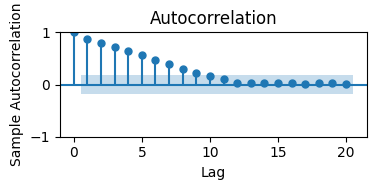

In [11]:
#| echo: false
#| label: fig-acf-residual6-all
#| fig-cap: "Sample Autocorrelation function plot of SARIMA6 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima6.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

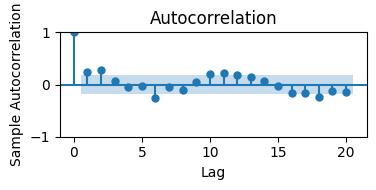

In [12]:
#| echo: false
#| label: fig-acf-residual9-all
#| fig-cap: "Sample Autocorrelation function plot of SARIMA9 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima9.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

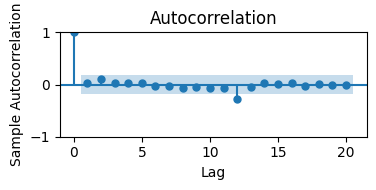

In [13]:
#| echo: false
#| label: fig-acf-residual12-all
#| fig-cap: "Sample Autocorrelation function plot of SARIMA12 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima12.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

Models split by pre, during, post

In [14]:
edges = [pd.Timestamp("2017-01-01"),pd.Timestamp("2020-03-01",), pd.Timestamp("2022-07-01"), pd.Timestamp("2100-01-01")]

labels = ["pre", "during", "post"]

crime_monthly["covid"] = pd.cut(crime_monthly["Month"], bins=edges, labels=labels, right=False)

Pre

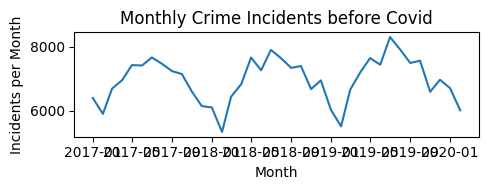

In [15]:
#| fig-cap: "Time plot of Incidents per Month Pre-Covid"

pre_covid = crime_monthly[crime_monthly["covid"] == "pre"]

# Plot
plt.figure(figsize=(5, 2))
plt.title("Monthly Crime Incidents before Covid")
plt.plot(pre_covid['Month'], pre_covid['Incidents'], '-')
plt.xlabel('Month')
plt.ylabel('Incidents per Month')
plt.tight_layout()
plt.show()

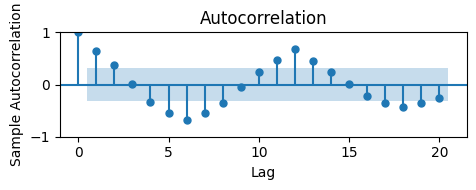

In [16]:
#| label: fig-acf-incidents-pre
#| fig-cap: "Sample Autocorrelation function (Pre-covid)"

fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(pre_covid['Incidents'], ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

During

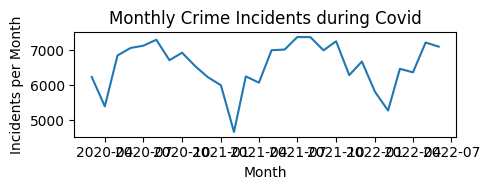

In [17]:
#| fig-cap: "Time plot of Incidents per Month during Covid"

during_covid = crime_monthly[crime_monthly["covid"] == "during"]

# Plot
plt.figure(figsize=(5, 2))
plt.title("Monthly Crime Incidents during Covid")
plt.plot(during_covid['Month'], during_covid['Incidents'], '-')
plt.xlabel('Month')
plt.ylabel('Incidents per Month')
plt.tight_layout()
plt.show()

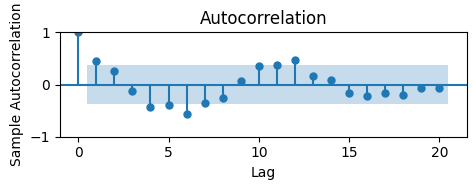

In [18]:
#| label: fig-acf-incidents-during
#| fig-cap: "Sample Autocorrelation function (During covid)"

fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(during_covid['Incidents'], ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

Post

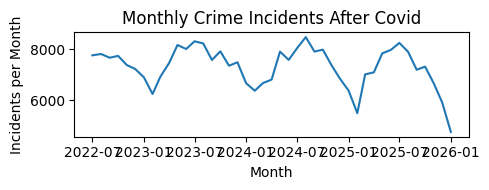

In [19]:
#| fig-cap: "Time plot of Incidents per Month After Covid"
post_covid = crime_monthly[crime_monthly["covid"] == "post"]

# Plot
plt.figure(figsize=(5, 2))
plt.title("Monthly Crime Incidents After Covid")
plt.plot(post_covid['Month'], post_covid['Incidents'], '-')
plt.xlabel('Month')
plt.ylabel('Incidents per Month')
plt.tight_layout()
plt.show()

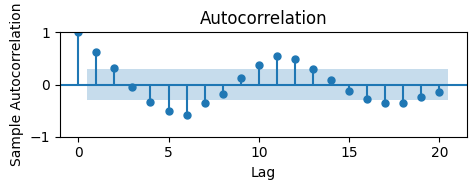

In [20]:
#| label: fig-acf-incidents-post
#| fig-cap: "Sample Autocorrelation function (Post-covid)"

fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(post_covid['Incidents'], ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

**Model Fitting (Pre, During, Post)**

PRE

In [21]:
monthly_incident_count = pre_covid['Incidents']

crime_sarima1_pre = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(1, 1, 0, 12)).fit()

crime_sarima2_pre = SARIMAX(monthly_incident_count, order=(0,0,1), trend='c',seasonal_order=(0, 1, 1, 12)).fit()

crime_sarima3_pre = SARIMAX(monthly_incident_count, order=(1,0,1), trend='c',seasonal_order=(1, 1, 1, 12)).fit()

crime_sarima4_pre = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(2, 1, 0, 12)).fit()

crime_sarima5_pre = SARIMAX(monthly_incident_count, order=(0,0,1), trend='c',seasonal_order=(1, 1, 0, 12)).fit()

crime_sarima6_pre = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(1, 1, 1, 12)).fit()

crime_sarima7_pre = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(0, 1, 1, 12)).fit()

crime_sarima8_pre = SARIMAX(monthly_incident_count, order=(1,1,1), trend='c',seasonal_order=(1, 1, 1, 12)).fit()

crime_sarima9_pre = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(1, 0, 0,12)).fit()

crime_sarima10_pre = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(1, 1, 0, 12)).fit()

crime_sarima11_pre = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 1, 0,12)).fit()

crime_sarima12_pre = SARIMAX(monthly_incident_count, order=(0,1,1), trend='c', seasonal_order=(0, 1, 1,12)).fit()

crime_sarima13_pre = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 0, 0, 12)).fit()

crime_sarima13_pre = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 0, 1, 12)).fit()

crime_sarima14_pre = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 0, 0, 12)).fit()

Check AIC

In [22]:
#| echo: false
crime_sarima1_pre.aic.item()
crime_sarima2_pre.aic.item() 
crime_sarima3_pre.aic.item()
crime_sarima4_pre.aic.item() 
crime_sarima5_pre.aic.item()
crime_sarima6_pre.aic.item()
crime_sarima7_pre.aic.item()
crime_sarima8_pre.aic.item() 
crime_sarima9_pre.aic.item() 
crime_sarima10_pre.aic.item()
crime_sarima11_pre.aic.item()
crime_sarima12_pre.aic.item() 
crime_sarima13_pre.aic.item() 
crime_sarima14_pre.aic.item()

588.5915663624921

Coefficients for all models aren't significant. Should choose a simpler model? AR(1) worked. 

In [23]:
print(crime_sarima12_pre.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     18.1308      7.712      2.351      0.019       3.016      33.246
ma.L1         -0.9991     14.023     -0.071      0.943     -28.484      26.486
ma.S.L12      -0.0576      0.233     -0.247      0.805      -0.515       0.400
sigma2      5.825e+04   8.06e+05      0.072      0.942   -1.52e+06    1.64e+06


Residual Check

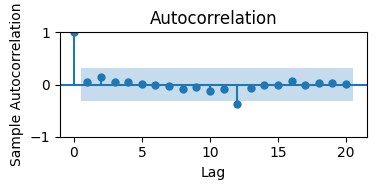

In [24]:
#| echo: false
#| label: fig-acf-residual12-pre
#| fig-cap: "Sample Autocorrelation function plot of SARIMA12 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima12_pre.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

DURING

In [25]:
monthly_incident_count = during_covid['Incidents']

crime_sarima1_dur = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(1, 1, 0, 12)).fit()

crime_sarima2_dur = SARIMAX(monthly_incident_count, order=(0,0,1), trend='c',seasonal_order=(0, 1, 1, 12)).fit()

crime_sarima3_dur = SARIMAX(monthly_incident_count, order=(1,0,1), trend='c',seasonal_order=(1, 1, 1, 12)).fit()

crime_sarima4_dur = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(2, 1, 0, 12)).fit()

crime_sarima5_dur = SARIMAX(monthly_incident_count, order=(0,0,1), trend='c',seasonal_order=(1, 1, 0, 12)).fit()

crime_sarima6_dur = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(1, 1, 1, 12)).fit()

crime_sarima7_dur = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(0, 1, 1, 12)).fit()

crime_sarima8_dur = SARIMAX(monthly_incident_count, order=(1,1,1), trend='c',seasonal_order=(1, 1, 1, 12)).fit()

crime_sarima9_dur = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(1, 0, 0,12)).fit()

crime_sarima10_dur = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(1, 1, 0, 12)).fit()

crime_sarima11_dur = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 1, 0,12)).fit()

crime_sarima12_dur = SARIMAX(monthly_incident_count, order=(0,1,1), trend='c', seasonal_order=(0, 1, 1,12)).fit()

crime_sarima13_dur = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 0, 0, 12)).fit()

crime_sarima13_dur = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 0, 1, 12)).fit()

crime_sarima14_dur = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 0, 0, 12)).fit()

crime_sarima15_dur = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 1, 0, 12)).fit()

Check AIC

In [26]:
#| echo: false
crime_sarima1_dur.aic.item()
crime_sarima2_dur.aic.item() 
crime_sarima3_dur.aic.item()
crime_sarima4_dur.aic.item() 
crime_sarima5_dur.aic.item()
crime_sarima6_dur.aic.item()
crime_sarima7_dur.aic.item()
crime_sarima8_dur.aic.item() 
crime_sarima9_dur.aic.item() 
crime_sarima10_dur.aic.item()
crime_sarima11_dur.aic.item()
crime_sarima12_dur.aic.item() 
crime_sarima13_dur.aic.item() 
crime_sarima14_dur.aic.item()
crime_sarima15_dur.aic.item()

221.66735115064

In [27]:
print(crime_sarima11_dur.summary().tables[1])
print(crime_sarima13_dur.summary().tables[1])
print(crime_sarima14_dur.summary().tables[1])
print(crime_sarima15_dur.summary().tables[1])
print(crime_sarima12_dur.summary().tables[1]) # why does this have the best acf plot despite not having significant coeff

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    317.5237     78.446      4.048      0.000     163.773     471.274
ar.L1         -0.5458      0.240     -2.271      0.023      -1.017      -0.075
sigma2      4.175e+04   2.05e+04      2.040      0.041    1639.374    8.19e+04
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   3521.4585   1133.970      3.105      0.002    1298.918    5743.999
ar.L1          0.4628      0.180      2.564      0.010       0.109       0.817
ma.S.L12       0.9972      0.252      3.959      0.000       0.504       1.491
sigma2      1.437e+05      0.001   1.14e+08      0.000    1.44e+05    1.44e+05
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

Roots

In [28]:
ar_roots = crime_sarima11_dur.arroots
print("Magnitude of AR roots:", np.abs(ar_roots))

ma_roots = crime_sarima11_dur.maroots
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)
print("Magnitude of MA roots:", np.abs(ma_roots)) ## Too close to boundary

ar_roots = crime_sarima13_dur.arroots
print("Magnitude of AR roots:", np.abs(ar_roots))

ma_roots = crime_sarima13_dur.maroots
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)
print("Magnitude of MA roots:", np.abs(ma_roots)) ## Too close to boundary

ar_roots = crime_sarima14_dur.arroots
print("Magnitude of AR roots:", np.abs(ar_roots))

ar_roots = crime_sarima15_dur.arroots
print("Magnitude of AR roots:", np.abs(ar_roots))  # Too close to boundary

Magnitude of AR roots: [1.83233729]
Magnitude of MA roots > 1.1: []
Magnitude of MA roots: []
Magnitude of AR roots: [2.16068301]
Magnitude of MA roots > 1.1: [False False False False False False False False False False False False]
Magnitude of MA roots: [1.00023126 1.00023126 1.00023126 1.00023126 1.00023126 1.00023126
 1.00023126 1.00023126 1.00023126 1.00023126 1.00023126 1.00023126]
Magnitude of AR roots: [2.15747714]
Magnitude of AR roots: [1.83233729]


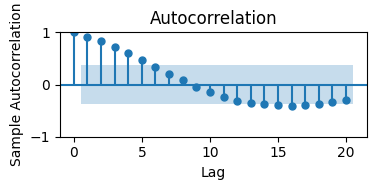

In [29]:
#| echo: false
#| label: fig-acf-residual11-during
#| fig-cap: "Sample Autocorrelation function plot of SARIMA11 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima11_dur.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

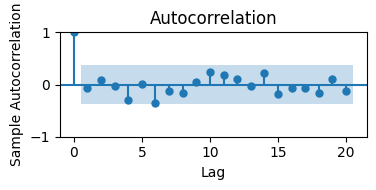

In [30]:
#| echo: false
#| label: fig-acf-residual13-during
#| fig-cap: "Sample Autocorrelation function plot of SARIMA13 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima13_dur.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

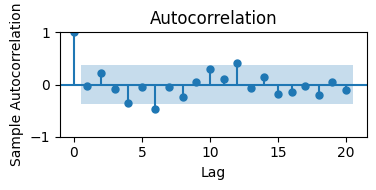

In [31]:
#| echo: false
#| label: fig-acf-residual14-during
#| fig-cap: "Sample Autocorrelation function plot of SARIMA14 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima14_dur.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

since SARIMA15 does not capture seasonality

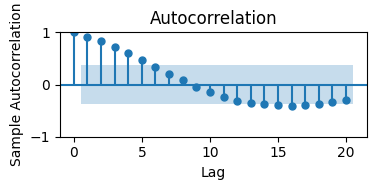

In [32]:
#| echo: false
#| label: fig-acf-residual15-during
#| fig-cap: "Sample Autocorrelation function plot of SARIMA15 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima15_dur.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

POST

In [33]:
monthly_incident_count = post_covid['Incidents']

crime_sarima1_post = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(1, 1, 0, 12)).fit()

crime_sarima2_post = SARIMAX(monthly_incident_count, order=(0,0,1), trend='c',seasonal_order=(0, 1, 1, 12)).fit()

crime_sarima3_post = SARIMAX(monthly_incident_count, order=(1,0,1), trend='c',seasonal_order=(1, 1, 1, 12)).fit()

crime_sarima4_post = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(2, 1, 0, 12)).fit()

crime_sarima5_post = SARIMAX(monthly_incident_count, order=(0,0,1), trend='c',seasonal_order=(1, 1, 0, 12)).fit()

crime_sarima6_post = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(1, 1, 1, 12)).fit()

crime_sarima7_post = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c',seasonal_order=(0, 1, 1, 12)).fit()

crime_sarima8_post = SARIMAX(monthly_incident_count, order=(1,1,1), trend='c',seasonal_order=(1, 1, 1, 12)).fit()

crime_sarima9_post = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(1, 0, 0,12)).fit()

crime_sarima10_post = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(1, 1, 0, 12)).fit()

crime_sarima11_post = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 1, 0,12)).fit()

crime_sarima12_post = SARIMAX(monthly_incident_count, order=(0,1,1), trend='c', seasonal_order=(0, 1, 1,12)).fit()

crime_sarima13_post = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 0, 0, 12)).fit()

crime_sarima13_post = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 0, 1, 12)).fit()

crime_sarima14_post = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 0, 0, 12)).fit()

crime_sarima15_post = SARIMAX(monthly_incident_count, order=(1,0,0), trend='c', seasonal_order=(0, 1, 0, 12)).fit()

Check AIC

In [34]:
#| echo: false
crime_sarima1_post.aic.item()
crime_sarima2_post.aic.item() 
crime_sarima3_post.aic.item()
crime_sarima4_post.aic.item() 
crime_sarima5_post.aic.item()
crime_sarima6_post.aic.item()
crime_sarima7_post.aic.item()
crime_sarima8_post.aic.item() 
crime_sarima9_post.aic.item() 
crime_sarima10_post.aic.item()
crime_sarima11_post.aic.item()
crime_sarima12_post.aic.item() 
crime_sarima13_post.aic.item() 
crime_sarima14_post.aic.item()
crime_sarima15_post.aic.item()

465.03319951077367

In [35]:
# print(crime_sarima6_post.summary().tables[1]) # intercept insignificant
print(crime_sarima9_post.summary().tables[1]) 
print(crime_sarima11_post.summary().tables[1]) # best AIC
print(crime_sarima13_post.summary().tables[1])
print(crime_sarima14_post.summary().tables[1])
print(crime_sarima15_post.summary().tables[1])
print(crime_sarima12_post.summary().tables[1]) # again, this shows the most reasonable ACF

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1192.4606    602.362      1.980      0.048      11.852    2373.069
ar.L1          0.5985      0.126      4.755      0.000       0.352       0.845
ar.S.L12       0.5882      0.230      2.563      0.010       0.138       1.038
sigma2      1.785e+05   4.94e+04      3.616      0.000    8.17e+04    2.75e+05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   -154.0730     79.664     -1.934      0.053    -310.211       2.065
ar.L1          0.4883      0.118      4.151      0.000       0.258       0.719
sigma2      1.482e+05   3.47e+04      4.267      0.000    8.01e+04    2.16e+05
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

Check Roots

In [36]:
ar_roots = crime_sarima6_post.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) # Too close to boundary

ma_roots = crime_sarima6_post.maroots
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)
print("Magnitude of MA roots:", np.abs(ma_roots)) # Too close to boundary

ar_roots = crime_sarima9_post.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) # Too close to boundary

ar_roots = crime_sarima11_post.arroots
print("Magnitude of AR roots:", np.abs(ar_roots)) # Too close to boundary

ar_roots = crime_sarima13_post.arroots
print("Magnitude of AR roots:", np.abs(ar_roots))

ma_roots = crime_sarima13_post.maroots
print("Magnitude of MA roots > 1.1:", np.abs(ma_roots) > 1.1)
print("Magnitude of MA roots:", np.abs(ma_roots)) # Too close to boundary

ar_roots = crime_sarima14_post.arroots
print("Magnitude of AR roots:", np.abs(ar_roots))

ar_roots = crime_sarima15_post.arroots
print("Magnitude of AR roots:", np.abs(ar_roots))

Magnitude of AR roots: [1.00000435 1.00000435 1.00000435 1.00000435 1.00000435 1.00000435
 1.00000435 1.00000435 1.00000435 1.00000435 1.00000435 1.00000435
 1.91137505]
Magnitude of MA roots > 1.1: [False False False False False False False False False False False False]
Magnitude of MA roots: [1.00029099 1.00029099 1.00029099 1.00029099 1.00029099 1.00029099
 1.00029099 1.00029099 1.00029099 1.00029099 1.00029099 1.00029099]
Magnitude of AR roots: [1.04521459 1.04521459 1.04521459 1.04521459 1.04521459 1.04521459
 1.04521459 1.04521459 1.04521459 1.04521459 1.04521459 1.04521459
 1.67070644]
Magnitude of AR roots: [2.04781282]
Magnitude of AR roots: [1.20717356]
Magnitude of MA roots > 1.1: [False False False False False False False False False False False False]
Magnitude of MA roots: [1.05643425 1.05643425 1.05643425 1.05643425 1.05643425 1.05643425
 1.05643425 1.05643425 1.05643425 1.05643425 1.05643425 1.05643425]
Magnitude of AR roots: [1.20292694]
Magnitude of AR roots: [2.0478

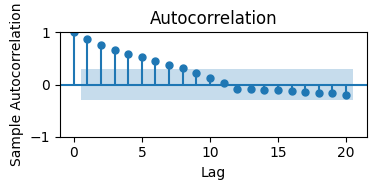

In [37]:
#| echo: false
#| label: fig-acf-residual6-post
#| fig-cap: "Sample Autocorrelation function plot of SARIMA6 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima6_post.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

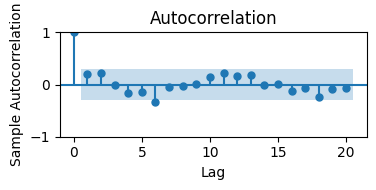

In [38]:
#| echo: false
#| label: fig-acf-residual9-post
#| fig-cap: "Sample Autocorrelation function plot of SARIMA9 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima9_post.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

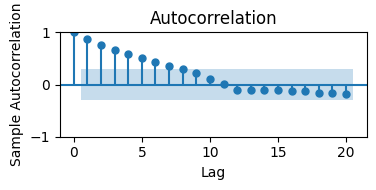

In [39]:
#| echo: false
#| label: fig-acf-residual11-post
#| fig-cap: "Sample Autocorrelation function plot of SARIMA11 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima11_post.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

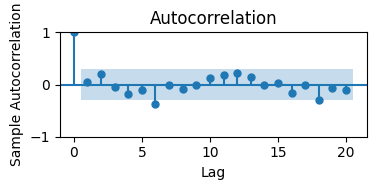

In [40]:
#| echo: false
#| label: fig-acf-residual13-post
#| fig-cap: "Sample Autocorrelation function plot of SARIMA13 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima13_post.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

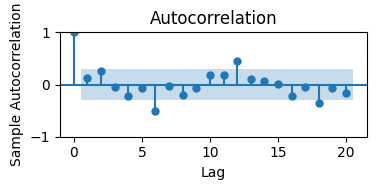

In [41]:
#| echo: false
#| label: fig-acf-residual14-post
#| fig-cap: "Sample Autocorrelation function plot of SARIMA14 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima14_post.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

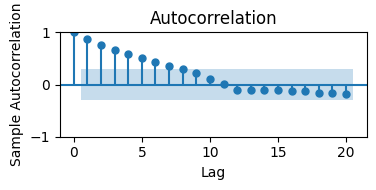

In [42]:
#| echo: false
#| label: fig-acf-residual15-post
#| fig-cap: "Sample Autocorrelation function plot of SARIMA15 residuals"
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima15_post.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

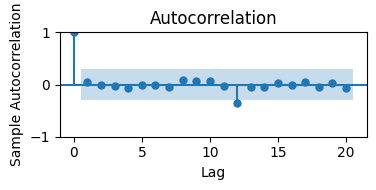

In [43]:
#| echo: false
#| label: fig-acf-residual12-post
#| fig-cap: "Sample Autocorrelation function plot of SARIMA12 residuals" # this one had insignificant coefficients
fig, ax = plt.subplots(figsize=(4, 2))
plot_acf(crime_sarima12_post.resid, ax = ax, lags=20, bartlett_confint=False)
plt.xlabel('Lag'); plt.ylabel('Sample Autocorrelation')
plt.tight_layout(); plt.show()

Questions to ask:
1) Why do we see insignificant coeffcicients in some cases, but the ACF plot shows iid residuals. 


# Unemployment Data

**Exploratory Data Analysis**

**Check Roots**

**Residual Analysis**